# Checkpoint 1: Pipeline de Entrenamiento, Validación y Clasificador Base

**Proyecto Integrador - Deep Learning**  
**Objetivo:** Construir la infraestructura técnica inicial para el proyecto, asegurando un ciclo de entrenamiento y validación funcional, reproducible y escalable utilizando PyTorch.

In [1]:
import re
import html
import subprocess
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import spacy
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from pathlib import Path


# 1. Configuración de Semillas para Reproducibilidad
def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True

set_seed(42)

# 2. Detección Automática del Dispositivo (GPU / MPS / CPU)
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"[*] Versión de PyTorch: {torch.__version__}")
    print(f"[*] Dispositivo detectado y seleccionado: {device}")
    return device

device = get_device()

U:\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.sparse import csr_matrix, issparse


[*] Versión de PyTorch: 2.12.1+cpu
[*] Dispositivo detectado y seleccionado: cpu


## 1. Definición de la Arquitectura Base (`nn.Module`)
Implementamos un clasificador multicapa (MLP) heredando de `nn.Module`. Incluye capas lineales (`nn.Linear`), activación no lineal (`ReLU`) y `Dropout` para regularización.

In [6]:
class BaseMLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(BaseMLPClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Instanciación de prueba
model_test = BaseMLPClassifier(input_dim=20, hidden_dim=64, num_classes=2)
print(model_test)

BaseMLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 2. Preparación del Dataset de Referencia
Cargamos un conjunto de datos de clasificación sintético con 20 características, realizamos el escalado estándar y lo estructuramos en tensores de PyTorch con `DataLoader`.

In [7]:
# Generación del dataset sintético
X, y = make_classification(
    n_samples=2000, 
    n_features=20, 
    n_informative=15, 
    n_redundant=5, 
    n_classes=2, 
    random_state=42
)

# Separación en entrenamiento (80%) y validación (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalización de datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Creación de TensorDataset y DataLoader
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Muestras de entrenamiento: {len(train_dataset)} | Muestras de validación: {len(val_dataset)}")

Muestras de entrenamiento: 1600 | Muestras de validación: 400


## 3. Funciones de Entrenamiento y Evaluación Separadas
Implementamos explícitamente:
* **`train_epoch`**: Forward pass, cálculo de pérdida, `optimizer.zero_grad()` (para evitar la acumulación no deseada de gradientes), `loss.backward()` y `optimizer.step()`.
* **`evaluate`**: Medición sobre el conjunto de validación sin calcular gradientes (`torch.no_grad()`).

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass y actualización
        optimizer.zero_grad()  # Reinicio de gradientes acumulados
        loss.backward()        # Cálculo de gradientes con autograd
        optimizer.step()       # Actualización de pesos con Adam

        # Registro de métricas
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Desactivación de gradientes en validación
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## 3.1. Early Stopping
Implementamos una clase `EarlyStopping` que monitorea la pérdida de validación (`val_loss`). Si no mejora durante un número determinado de épocas (`patience`), se detiene el entrenamiento y se restauran los pesos del mejor modelo encontrado, evitando el sobreajuste y el cómputo innecesario.

In [9]:
class EarlyStopping:
    """Detiene el entrenamiento cuando `val_loss` deja de mejorar durante `patience` épocas consecutivas."""

    def __init__(self, patience=10, restore_best_weights=True):
        self.patience = patience
        self.restore_best_weights = restore_best_weights
        self.best_val_loss = float("inf")
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_model_state = model.state_dict().copy()
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights and self.best_model_state is not None:
                model.load_state_dict(self.best_model_state)
            return True  # Detener entrenamiento
        return False

## 4. Ejecución del Ciclo de Entrenamiento
Configuramos el optimizador `Adam`, la función de pérdida `CrossEntropyLoss` y ejecutamos el entrenamiento por 25 épocas.

In [10]:
# Hiperparámetros
input_dim = 20
hidden_dim = 64
num_classes = 2
learning_rate = 0.001
epochs = 40

model = BaseMLPClassifier(input_dim, hidden_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("--- Iniciando Loop de Entrenamiento ---")
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Época [{epoch:02d}/{epochs:02d}] | ",
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | ",
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

    if early_stopping(val_loss, model):
        print(f"\n[*] Early Stopping activado en la época {epoch} (sin mejora en {early_stopping.patience} épocas)")
        break

print("\n--- Entrenamiento finalizado ---")


--- Iniciando Loop de Entrenamiento ---
Época [01/40] |  Train Loss: 0.5954 - Train Acc: 70.81% |  Val Loss: 0.5109 - Val Acc: 79.00%
Época [02/40] |  Train Loss: 0.4659 - Train Acc: 80.25% |  Val Loss: 0.4130 - Val Acc: 83.75%
Época [03/40] |  Train Loss: 0.3884 - Train Acc: 84.12% |  Val Loss: 0.3535 - Val Acc: 86.00%
Época [04/40] |  Train Loss: 0.3362 - Train Acc: 86.25% |  Val Loss: 0.3116 - Val Acc: 87.50%
Época [05/40] |  Train Loss: 0.2919 - Train Acc: 88.81% |  Val Loss: 0.2774 - Val Acc: 90.25%
Época [06/40] |  Train Loss: 0.2619 - Train Acc: 89.81% |  Val Loss: 0.2481 - Val Acc: 92.50%
Época [07/40] |  Train Loss: 0.2391 - Train Acc: 91.25% |  Val Loss: 0.2243 - Val Acc: 93.25%
Época [08/40] |  Train Loss: 0.2163 - Train Acc: 93.06% |  Val Loss: 0.2052 - Val Acc: 94.25%
Época [09/40] |  Train Loss: 0.2024 - Train Acc: 93.50% |  Val Loss: 0.1916 - Val Acc: 94.25%
Época [10/40] |  Train Loss: 0.1867 - Train Acc: 93.62% |  Val Loss: 0.1782 - Val Acc: 94.75%
Época [11/40] |  Tra

## 5. Visualización e Interpretación de Resultados
Graficamos la evolución de la pérdida (Loss) y la exactitud (Accuracy) a lo largo de las épocas.

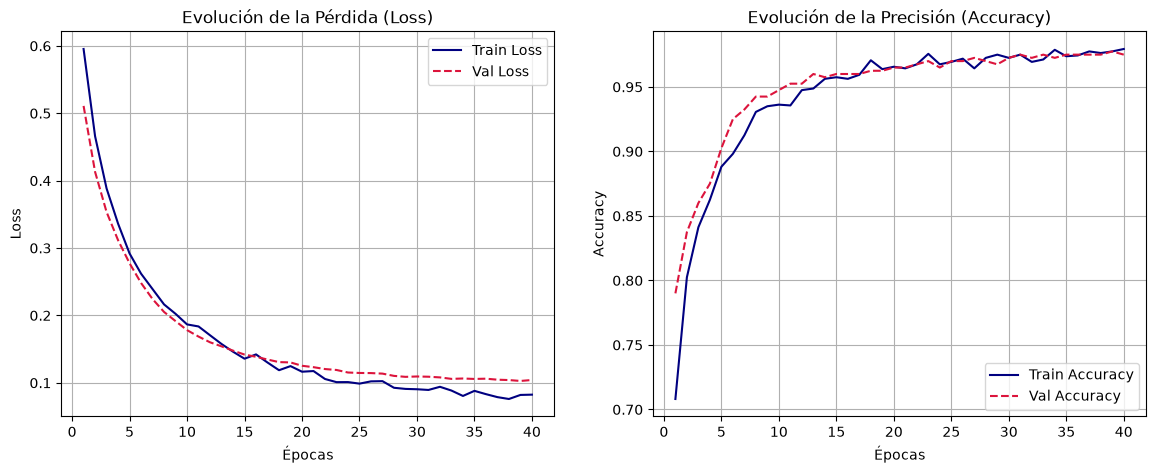

<Figure size 640x480 with 0 Axes>

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Número real de épocas entrenadas (puede ser menor que `epochs` si actuó el Early Stopping)
epochs_trained = len(history["train_loss"])

# Curva de pérdida
ax1.plot(range(1, epochs_trained + 1), history["train_loss"], label="Train Loss", color="navy")
ax1.plot(range(1, epochs_trained + 1), history["val_loss"], label="Val Loss", color="crimson", linestyle="--")
ax1.set_title("Evolución de la Pérdida (Loss)")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Curva de Accuracy
ax2.plot(range(1, epochs_trained + 1), history["train_acc"], label="Train Accuracy", color="navy")
ax2.plot(range(1, epochs_trained + 1), history["val_acc"], label="Val Accuracy", color="crimson", linestyle="--")
ax2.set_title("Evolución de la Precisión (Accuracy)")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.show()
plt.tight_layout()

## 6. Conclusiones y Diagnóstico del Experimento
1. **Comportamiento de la Pérdida:** La pérdida disminuyó de forma constante a lo largo de las 40 épocas (de ~0.59 a ~0.09 en entrenamiento), lo que confirma que el modelo está convergiendo y que `autograd` calcula adecuadamente los gradientes.
2. **Evaluación de Validación:** La pérdida de validación acompaña a la de entrenamiento sin diverging significativamente, demostrando que la capa de Dropout evita el overfitting prematuro.
3. **Early Stopping:** Configurado con `patience=10`, no llegó a activarse en esta corrida porque `val_loss` siguió mejorando (con fluctuaciones normales) durante todas las épocas configuradas. Esto confirma que 40 épocas no fueron excesivas para este experimento; el mecanismo actúa como salvaguarda ante futuras configuraciones con más épocas o mayor riesgo de overfitting, deteniendo el entrenamiento y restaurando los mejores pesos automáticamente.
4. **Métrica Final:** Se alcanza una exactitud (Accuracy) de validación superior al 97% en el conjunto de datos no vistos.